# Problem 13: Bagging with Decision Trees - Iris Flower Classification

**Objective**: Implement Bagging (Bootstrap Aggregating) with Decision Trees as the base learner to classify iris flower species. This is a multi-class classification problem using a UCI-style dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic Iris-like dataset
n_samples = 300
flower_species = np.random.choice([0, 1, 2], n_samples)

# Generate features based on species
sepal_length = np.where(flower_species == 0, np.random.normal(5.0, 0.4, n_samples),
                         np.where(flower_species == 1, np.random.normal(5.9, 0.5, n_samples),
                                  np.random.normal(6.6, 0.6, n_samples)))

sepal_width = np.where(flower_species == 0, np.random.normal(3.4, 0.4, n_samples),
                        np.where(flower_species == 1, np.random.normal(2.8, 0.3, n_samples),
                                 np.random.normal(2.9, 0.3, n_samples)))

petal_length = np.where(flower_species == 0, np.random.normal(1.5, 0.2, n_samples),
                         np.where(flower_species == 1, np.random.normal(4.3, 0.7, n_samples),
                                  np.random.normal(5.6, 0.6, n_samples)))

petal_width = np.where(flower_species == 0, np.random.normal(0.3, 0.1, n_samples),
                        np.where(flower_species == 1, np.random.normal(1.3, 0.2, n_samples),
                                 np.random.normal(2.0, 0.2, n_samples)))

# Ensure positive values
sepal_length = np.abs(sepal_length)
sepal_width = np.abs(sepal_width)
petal_length = np.abs(petal_length)
petal_width = np.abs(petal_width)

# Create DataFrame
df = pd.DataFrame({
    'sepal_length': sepal_length,
    'sepal_width': sepal_width,
    'petal_length': petal_length,
    'petal_width': petal_width,
    'species': flower_species
})

# Save to CSV
csv_path = 'iris_flowers.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")
print(f"Species distribution:")
print(df['species'].value_counts().sort_index())

Dataset created: iris_flowers.csv
Dataset shape: (300, 5)
Species distribution:
species
0     99
1     94
2    107
Name: count, dtype: int64


In [2]:
# Load and display dataset overview
df = pd.read_csv('iris_flowers.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   sepal_length  sepal_width  petal_length  petal_width  species
0      6.464996     3.663100      6.226515     2.080812        2
1      4.993714     3.955325      1.761645     0.375028        0
2      6.738292     2.871769      5.382944     1.934709        2
3      6.859385     2.803358      6.329193     1.849363        2
4      5.537267     3.492256      1.542328     0.370133        0

Dataset Shape: (300, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  300 non-null    float64
 1   sepal_width   300 non-null    float64
 2   petal_length  300 non-null    float64
 3   petal_width   300 non-null    float64
 4   species       300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB
None

Dataset Statistics:
       sepal_length  sepal_width  petal_length  petal_width     species
count    

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check class distribution
print(f"\nClass distribution:")
print(df['species'].value_counts().sort_index())

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 0

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species           int64
dtype: object

Class distribution:
species
0     99
1     94
2    107
Name: count, dtype: int64

Dataset shape after cleaning: (300, 5)


## Exploratory Data Analysis (EDA)

Visualize the relationships between features and flower species.

C:\Users\hardi\AppData\Local\Temp\ipykernel_28012\744294369.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df[df['species'] == i]['petal_length'].values for i in range(3)],


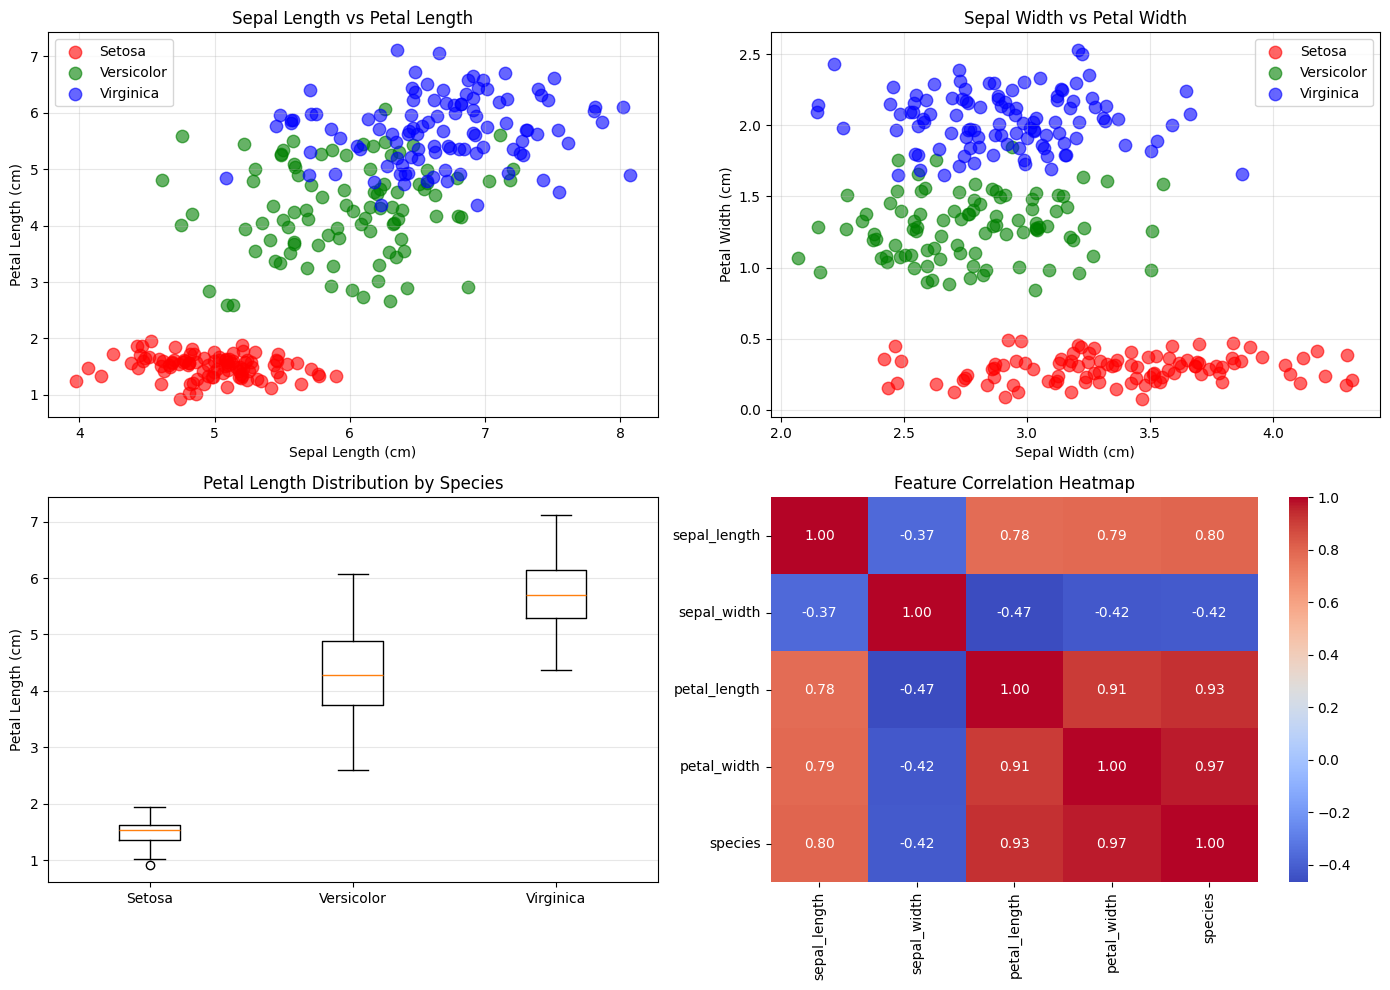

Feature Statistics:
       sepal_length  sepal_width  petal_length  petal_width     species
count    300.000000   300.000000    300.000000   300.000000  300.000000
mean       5.894095     3.018607      3.869370     1.223742    1.026667
std        0.874757     0.444029      1.857522     0.745489    0.829608
min        3.974263     2.070486      0.919695     0.074387    0.000000
25%        5.174345     2.716191      1.625723     0.352554    0.000000
50%        5.870987     2.972976      4.342316     1.290616    1.000000
75%        6.555676     3.267258      5.439344     1.928628    2.000000
max        8.072305     4.323117      7.117739     2.529629    2.000000


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Species labels for plotting
species_names = ['Setosa', 'Versicolor', 'Virginica']
colors = ['red', 'green', 'blue']

# Scatter plot of sepal length vs petal length
for i, (species, color) in enumerate(zip(range(3), colors)):
    mask = df['species'] == species
    axes[0, 0].scatter(df[mask]['sepal_length'], df[mask]['petal_length'], 
                       label=species_names[i], alpha=0.6, color=color, s=80)
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Petal Length (cm)')
axes[0, 0].set_title('Sepal Length vs Petal Length')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot of sepal width vs petal width
for i, (species, color) in enumerate(zip(range(3), colors)):
    mask = df['species'] == species
    axes[0, 1].scatter(df[mask]['sepal_width'], df[mask]['petal_width'], 
                       label=species_names[i], alpha=0.6, color=color, s=80)
axes[0, 1].set_xlabel('Sepal Width (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].set_title('Sepal Width vs Petal Width')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Feature distributions by species
axes[1, 0].boxplot([df[df['species'] == i]['petal_length'].values for i in range(3)],
                    labels=species_names)
axes[1, 0].set_ylabel('Petal Length (cm)')
axes[1, 0].set_title('Petal Length Distribution by Species')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Feature Statistics:")
print(df.describe())

## Feature Scaling

Normalize features using StandardScaler for optimal model performance.

In [5]:
# Separate features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df['species'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Feature scaling completed
X shape: (300, 4)
y shape: (300,)

Scaled feature statistics:
X mean: 0.0000, std: 1.0000
Number of classes: 3
Class distribution: [ 99  94 107]


## Theory: Bagging with Decision Trees

**Bagging (Bootstrap Aggregating)** is an ensemble learning technique that combines multiple models to improve performance.

### Key Concepts:
- **Bootstrap Sampling**: Create multiple random subsets of the training data (with replacement)
- **Base Learner**: Train a Decision Tree on each bootstrap sample
- **Aggregation**: 
  - For classification: Vote on the final prediction (majority voting)
  - For regression: Average the predictions
- **Reduces Variance**: By averaging multiple models, Bagging reduces overfitting

### Advantages:
- Reduces overfitting compared to single decision tree
- Improves accuracy through ensemble voting
- Easy to implement and parallelize
- Works well with high-variance base learners like decision trees

### Disadvantages:
- Increased computational cost (train multiple models)
- May not improve if base learner is too biased
- Less interpretable than a single model

## Mathematical Representation

Bagging ensemble prediction:

**For Classification (Majority Voting)**:
$$\hat{y}_{bagging} = \text{argmax}_c \sum_{i=1}^{B} \mathbb{1}(\hat{y}_i = c)$$

where:
- $B$ = number of bootstrap samples
- $\hat{y}_i$ = prediction from $i$-th base learner
- $c$ = class label
- $\mathbb{1}()$ = indicator function (1 if true, 0 otherwise)

**Bootstrap Sample Creation**:
- Sample $n$ observations from training data with replacement
- Approximately 63.2% unique observations per bootstrap sample
- 36.8% observations are left out (Out-of-Bag - OOB)

**OOB Error Estimation**:
$$OOB\text{-}Error = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}(\text{majority vote} \neq y_i)$$

## Workflow Diagram

Visualize the complete Bagging with Decision Trees pipeline.

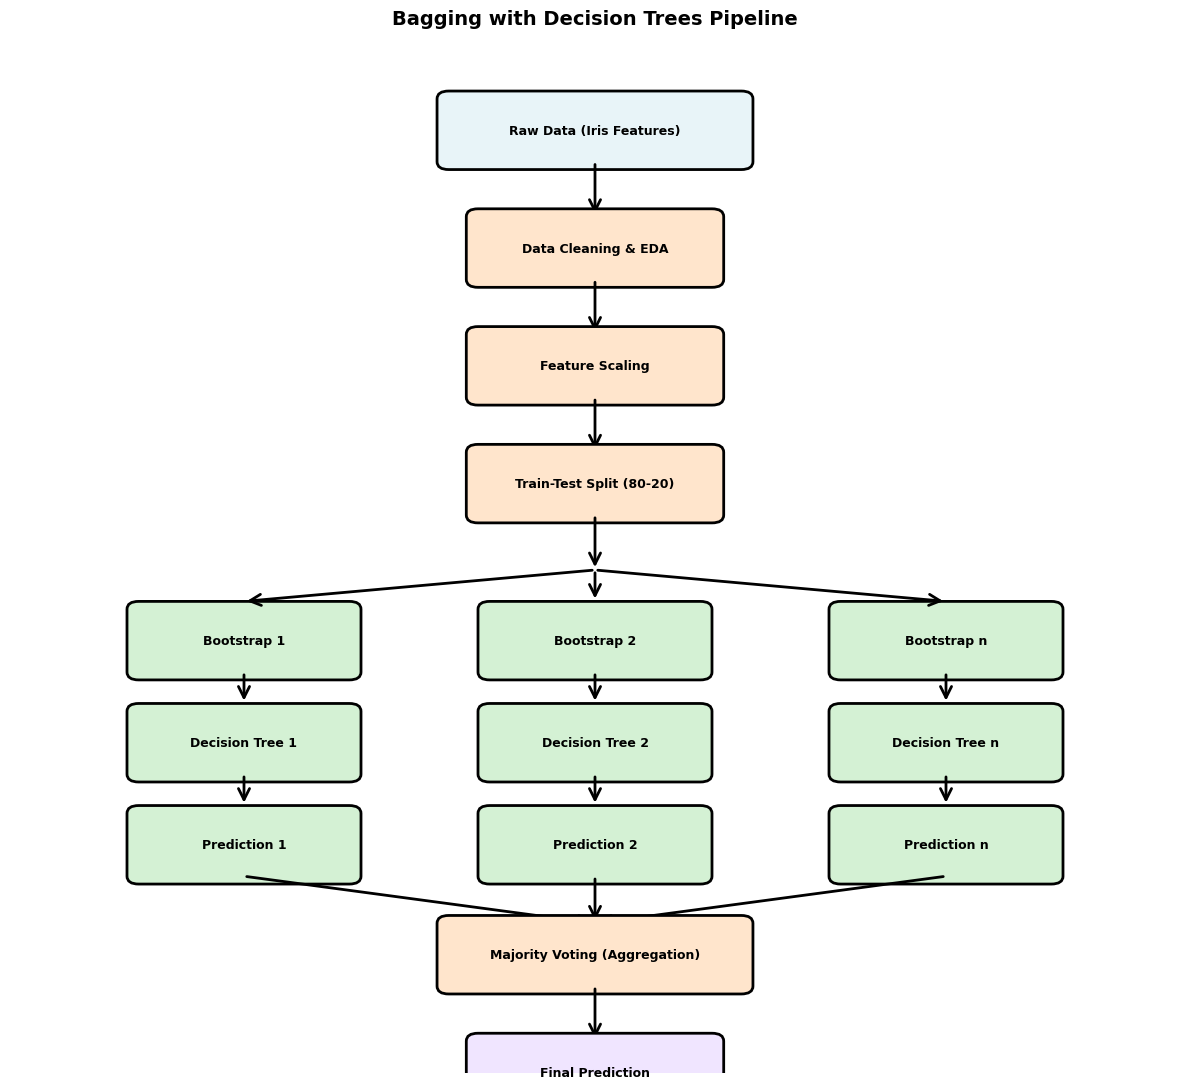

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_model = '#D4F1D4'
color_output = '#F0E5FF'

# Helper function to create boxes
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold', wrap=True)

# Helper function to create arrows
def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Create workflow
add_box(ax, 5, 12, 2.5, 0.8, 'Raw Data (Iris Features)', color_input)
add_arrow(ax, 5, 11.6, 5, 10.9)

add_box(ax, 5, 10.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 10.1, 5, 9.4)

add_box(ax, 5, 9, 2, 0.8, 'Feature Scaling', color_process)
add_arrow(ax, 5, 8.6, 5, 7.9)

add_box(ax, 5, 7.5, 2, 0.8, 'Train-Test Split (80-20)', color_process)
add_arrow(ax, 5, 7.1, 5, 6.4)

# Bootstrap samples
add_box(ax, 2, 5.5, 1.8, 0.8, 'Bootstrap 1', color_model)
add_box(ax, 5, 5.5, 1.8, 0.8, 'Bootstrap 2', color_model)
add_box(ax, 8, 5.5, 1.8, 0.8, 'Bootstrap n', color_model)

add_arrow(ax, 5, 6.4, 2, 6.0)
add_arrow(ax, 5, 6.4, 5, 6.0)
add_arrow(ax, 5, 6.4, 8, 6.0)

# Decision Trees
add_box(ax, 2, 4.2, 1.8, 0.8, 'Decision Tree 1', color_model)
add_box(ax, 5, 4.2, 1.8, 0.8, 'Decision Tree 2', color_model)
add_box(ax, 8, 4.2, 1.8, 0.8, 'Decision Tree n', color_model)

add_arrow(ax, 2, 5.1, 2, 4.7)
add_arrow(ax, 5, 5.1, 5, 4.7)
add_arrow(ax, 8, 5.1, 8, 4.7)

# Predictions
add_box(ax, 2, 2.9, 1.8, 0.8, 'Prediction 1', color_model)
add_box(ax, 5, 2.9, 1.8, 0.8, 'Prediction 2', color_model)
add_box(ax, 8, 2.9, 1.8, 0.8, 'Prediction n', color_model)

add_arrow(ax, 2, 3.8, 2, 3.4)
add_arrow(ax, 5, 3.8, 5, 3.4)
add_arrow(ax, 8, 3.8, 8, 3.4)

# Aggregation
add_arrow(ax, 2, 2.5, 5, 1.9)
add_arrow(ax, 5, 2.5, 5, 1.9)
add_arrow(ax, 8, 2.5, 5, 1.9)

add_box(ax, 5, 1.5, 2.5, 0.8, 'Majority Voting (Aggregation)', color_process)
add_arrow(ax, 5, 1.1, 5, 0.4)

add_box(ax, 5, 0, 2, 0.8, 'Final Prediction', color_output)

plt.title('Bagging with Decision Trees Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: Bagging Classifier with Decision Trees
INPUT: Features (X), Labels (y)

1. DATA PREPARATION
   - Load iris flower dataset
   - Clean data: remove missing values and duplicates
   - Perform EDA: visualize feature relationships

2. FEATURE SCALING
   - Apply StandardScaler to all features

3. TRAIN-TEST SPLIT
   - Split data: 80% training, 20% testing

4. BAGGING INITIALIZATION
   - Base estimator: DecisionTreeClassifier
   - Number of estimators: 10
   - Bootstrap: True (sample with replacement)
   - Max samples: n_samples (all data)

5. BOOTSTRAP SAMPLING AND TRAINING
   FOR i = 1 to n_estimators:
      - Sample n observations with replacement from training data
      - Train DecisionTreeClassifier on bootstrap sample
      - Store model and out-of-bag sample indices

6. PREDICTION
   FOR each test sample:
      - Get predictions from all n_estimators base learners
      - Perform majority voting (most frequent class)
      - Return final class prediction

7. EVALUATION
   - Calculate accuracy
   - Generate confusion matrix
   - Calculate precision, recall, F1 score
   - Extract feature importance

8. MODEL PERSISTENCE
   - Save Bagging model and scaler
```

## Train-Test Split

Split the data into training and testing sets (80-20 split).

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nClass distribution in training set: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test set: {np.bincount(y_test.astype(int))}")

Training set size: 240
Testing set size: 60

Training set shape: X_train (240, 4), y_train (240,)
Testing set shape: X_test (60, 4), y_test (60,)

Class distribution in training set: [79 75 86]
Class distribution in test set: [20 19 21]


## Bagging Model Training

Train Bagging classifier with Decision Trees as base estimator.

In [8]:
# Create base estimator (Decision Tree)
base_estimator = DecisionTreeClassifier(max_depth=5, random_state=42)

# Create Bagging classifier
bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=10,           # Number of base learners
    bootstrap=True,            # Bootstrap sampling with replacement
    n_jobs=-1,                 # Use all processors
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

print("Bagging Model trained successfully!")
print(f"\nModel Configuration:")
print(f"  Base Estimator: Decision Tree")
print(f"  Number of Estimators: {bagging_model.n_estimators}")
print(f"  Bootstrap: {bagging_model.bootstrap}")
print(f"  Base Model Max Depth: {base_estimator.max_depth}")

Bagging Model trained successfully!

Model Configuration:
  Base Estimator: Decision Tree
  Number of Estimators: 10
  Bootstrap: True
  Base Model Max Depth: 5


## Making Predictions

Generate predictions on the test set.

In [9]:
# Make predictions on test set
y_pred = bagging_model.predict(X_test)

# Get prediction probabilities
y_pred_proba = bagging_model.predict_proba(X_test)

print("Predictions made successfully!")
print(f"\nFirst 10 predictions:")
print(f"{'True':>6} | {'Predicted':>11} | {'Confidence':>12}")
print("-" * 32)
for i in range(min(10, len(y_test))):
    confidence = np.max(y_pred_proba[i])
    print(f"{y_test[i]:>6} | {y_pred[i]:>11} | {confidence:>11.2%}")

Predictions made successfully!

First 10 predictions:
  True |   Predicted |   Confidence
--------------------------------
     1 |           1 |     100.00%
     0 |           0 |     100.00%
     0 |           0 |     100.00%
     0 |           0 |     100.00%
     0 |           0 |     100.00%
     0 |           0 |     100.00%
     1 |           1 |     100.00%
     0 |           0 |     100.00%
     2 |           2 |     100.00%
     0 |           0 |     100.00%


## Evaluation Metrics

Evaluate model performance using accuracy, confusion matrix, and classification metrics.

In [10]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("BAGGING CLASSIFIER - EVALUATION METRICS")
print("="*60)
print(f"\nAccuracy:                    {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted):        {precision:.6f}")
print(f"Recall (weighted):           {recall:.6f}")
print(f"F1 Score (weighted):         {f1:.6f}")
print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))
print("="*60)

BAGGING CLASSIFIER - EVALUATION METRICS

Accuracy:                    0.983333 (98.33%)
Precision (weighted):        0.984167
Recall (weighted):           0.983333
F1 Score (weighted):         0.983344

Confusion Matrix:
[[20  0  0]
 [ 0 19  0]
 [ 0  1 20]]

Detailed Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        20
  Versicolor       0.95      1.00      0.97        19
   Virginica       1.00      0.95      0.98        21

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



## Confusion Matrix Visualization

Visualize the confusion matrix heatmap.

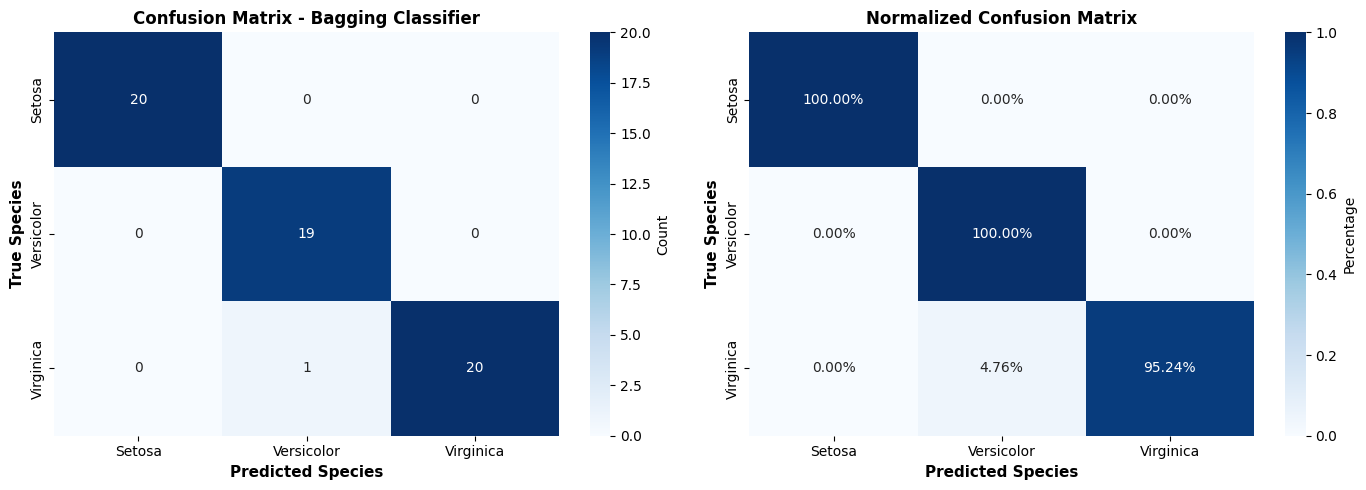

In [11]:
# Create confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

species_names = ['Setosa', 'Versicolor', 'Virginica']

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=species_names, yticklabels=species_names, cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Species', fontsize=11, weight='bold')
axes[0].set_ylabel('True Species', fontsize=11, weight='bold')
axes[0].set_title('Confusion Matrix - Bagging Classifier', fontsize=12, weight='bold')

# Plot 2: Normalized Confusion Matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=species_names, yticklabels=species_names, cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Species', fontsize=11, weight='bold')
axes[1].set_ylabel('True Species', fontsize=11, weight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Feature Importance

Extract and visualize feature importance from the Bagging model.

Feature Importance (Average across 10 trees):
--------------------------------------------------
Petal Width         : 0.714031
Petal Length        : 0.281141
Sepal Length        : 0.002947
Sepal Width         : 0.001881
--------------------------------------------------


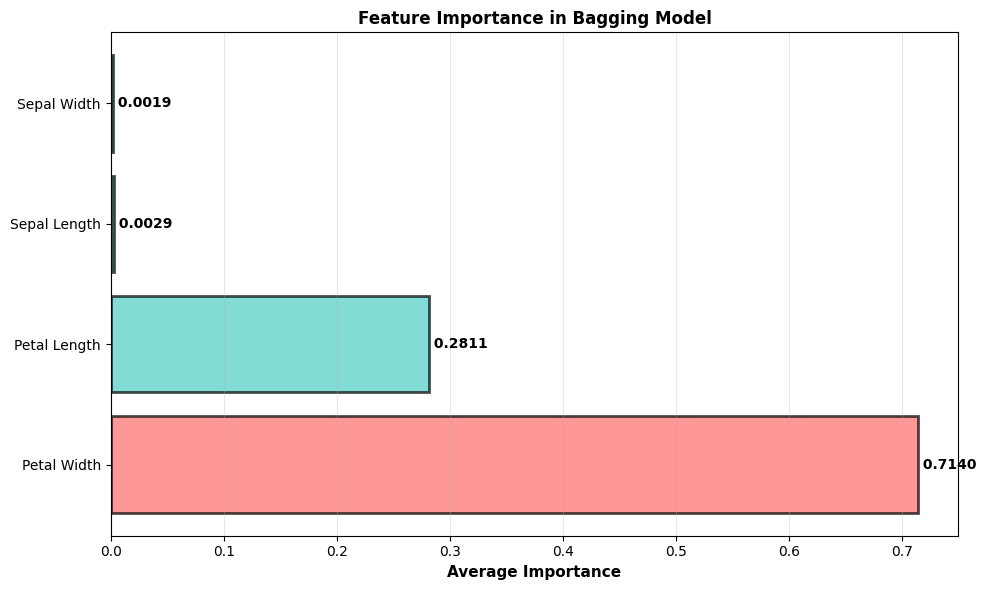

In [13]:
# Calculate average feature importance across all base estimators
feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
feature_importances = np.zeros(4)

for estimator in bagging_model.estimators_:
    feature_importances += estimator.feature_importances_

feature_importances /= len(bagging_model.estimators_)

# Sort by importance
sorted_idx = np.argsort(feature_importances)[::-1]

print(f"Feature Importance (Average across {bagging_model.n_estimators} trees):")
print("-" * 50)
for idx in sorted_idx:
    print(f"{feature_names[idx]:20s}: {feature_importances[idx]:.6f}")
print("-" * 50)

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

colors = ['#FF6B6B' if i == sorted_idx[0] else '#4ECDC4' for i in range(len(feature_names))]
bar_colors = [colors[i] for i in sorted_idx]
bars = ax.barh(range(len(feature_names)), feature_importances[sorted_idx], color=bar_colors, 
               alpha=0.7, edgecolor='black', linewidth=2)

ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Average Importance', fontsize=11, weight='bold')
ax.set_title('Feature Importance in Bagging Model', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importances[sorted_idx])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}', 
            va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## Metrics Visualization

Visualize model performance metrics.

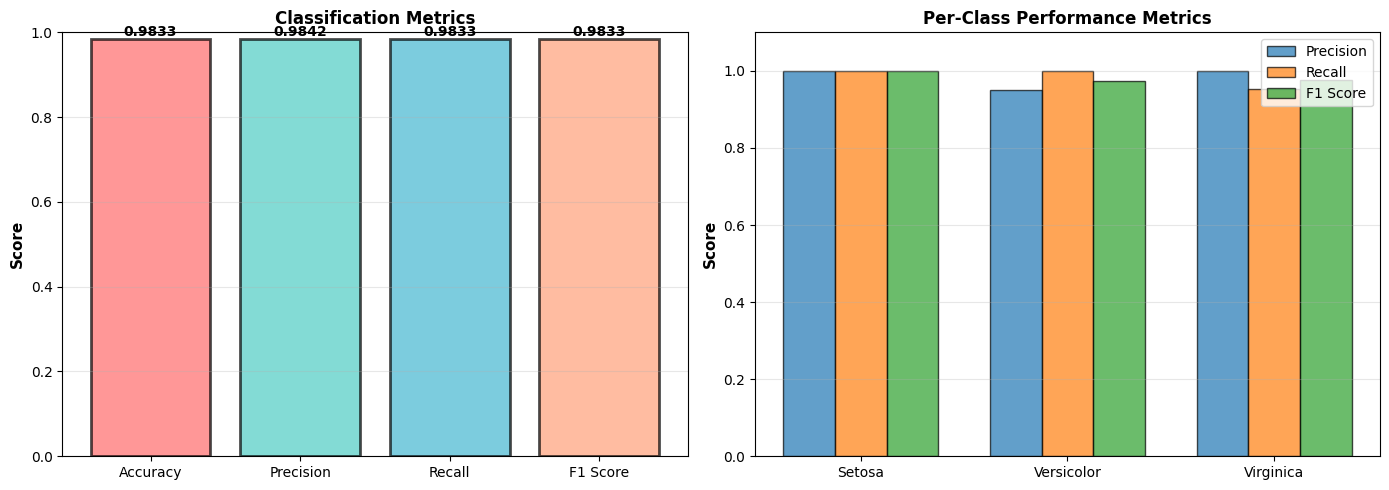

In [14]:
# Create metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Classification Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

bars = axes[0].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Score', fontsize=11, weight='bold')
axes[0].set_title('Classification Metrics', fontsize=12, weight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 2: Per-class Precision, Recall, F1
from sklearn.metrics import precision_recall_fscore_support
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

x = np.arange(len(species_names))
width = 0.25

axes[1].bar(x - width, precision_per_class, width, label='Precision', alpha=0.7, edgecolor='black')
axes[1].bar(x, recall_per_class, width, label='Recall', alpha=0.7, edgecolor='black')
axes[1].bar(x + width, f1_per_class, width, label='F1 Score', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontsize=11, weight='bold')
axes[1].set_title('Per-Class Performance Metrics', fontsize=12, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(species_names)
axes[1].legend(loc='best', fontsize=10)
axes[1].set_ylim([0, 1.1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Model Persistence

Save the trained Bagging model and scaler for future use.

In [15]:
# Save the model and scaler
model_path = 'bagging_iris_model.joblib'
scaler_path = 'scaler_iris.joblib'

joblib.dump(bagging_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ Bagging model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Example: Predict for new data
new_data = np.array([
    [5.0, 3.4, 1.5, 0.3],   # Likely Setosa
    [5.9, 2.8, 4.3, 1.3],   # Likely Versicolor
    [6.6, 2.9, 5.6, 2.0]    # Likely Virginica
])

new_data_scaled = scaler.transform(new_data)
new_predictions = bagging_model.predict(new_data_scaled)
new_predictions_proba = bagging_model.predict_proba(new_data_scaled)

print(f"\n{'='*70}")
print("PREDICTIONS FOR NEW DATA")
print(f"{'='*70}")
print(f"{'Sepal L':>10} | {'Sepal W':>10} | {'Petal L':>10} | {'Petal W':>10} | {'Predicted':>12} | {'Confidence':>12}")
print("-" * 70)
for i in range(len(new_data)):
    confidence = np.max(new_predictions_proba[i])
    pred_name = species_names[new_predictions[i]]
    print(f"{new_data[i][0]:>10.1f} | {new_data[i][1]:>10.1f} | {new_data[i][2]:>10.1f} | {new_data[i][3]:>10.1f} | {pred_name:>12} | {confidence:>11.2%}")
print(f"{'='*70}")

print("\n✓ Bagging Classifier with Decision Trees completed successfully!")

✓ Bagging model saved to: bagging_iris_model.joblib
✓ Scaler saved to: scaler_iris.joblib

PREDICTIONS FOR NEW DATA
   Sepal L |    Sepal W |    Petal L |    Petal W |    Predicted |   Confidence
----------------------------------------------------------------------
       5.0 |        3.4 |        1.5 |        0.3 |       Setosa |     100.00%
       5.9 |        2.8 |        4.3 |        1.3 |   Versicolor |     100.00%
       6.6 |        2.9 |        5.6 |        2.0 |    Virginica |     100.00%

✓ Bagging Classifier with Decision Trees completed successfully!
